In [ ]:
# %% [markdown]
# # SEL 1: Setup Environment & Import Library

import os
import sys
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Menambahkan root folder (Keperluan TA) ke dalam path sistem
# Ini wajib agar file di dalam folder 'notebooks' bisa memanggil file di folder 'models' dan 'scripts'
sys.path.append(os.path.abspath('..'))

# Import arsitektur model dari buatan Mba Meitha (Fungsi loss & metrik dihapus dari import)
from models.load_model_TA import build_unbcsm

# PERBAIKAN IMPORT SGD:
# Disesuaikan dengan versi keras yang digunakan pada file load_model_TA.py
from keras.optimizers import SGD 

# Import Data Generator yang sudah kita buat
from scripts.data_generator import ConjunctivaDataGenerator

print("Semua library berhasil di-import!")

Semua library berhasil di-import!


In [63]:
# %% [markdown]
# # SEL 2: Ekstraksi Path Dataset EyeDefy
# Di sel ini, kita menggunakan logika yang sama dengan file `cek_dataset_eyedefy.py` 
# untuk mengambil seluruh alamat file gambar asli dan mask-nya (ground truth).

# %%
def get_eyedefy_paths(dataset_root):
    image_paths = []
    mask_paths = []
    countries = ['India', 'Italy']
    
    for country in countries:
        country_path = os.path.join(dataset_root, country)
        if not os.path.exists(country_path):
            continue
            
        subfolders = [f.path for f in os.scandir(country_path) if f.is_dir()]
        
        for subfolder in subfolders:
            mask_search = glob.glob(os.path.join(subfolder, '*_forniceal_palpebral.*'))
            if len(mask_search) > 0:
                mask_file = mask_search[0]
                mask_filename = os.path.basename(mask_file)
                base_name = mask_filename.split('_forniceal_palpebral')[0]
                
                # Skenario 1: Nama persis sama (Contoh India: 20200118_164733.jpg)
                original_img_file_1 = os.path.join(subfolder, base_name + '.jpg')
                
                # Skenario 2: Angka 0 di depan dihilangkan (Contoh Italy: 002 -> 2.jpg)
                base_name_stripped = base_name.lstrip('0')
                if not base_name_stripped: # Jaga-jaga jika namanya kebetulan cuma '0'
                    base_name_stripped = '0'
                original_img_file_2 = os.path.join(subfolder, base_name_stripped + '.jpg')
                
                if os.path.exists(original_img_file_1):
                    image_paths.append(original_img_file_1)
                    mask_paths.append(mask_file)
                elif os.path.exists(original_img_file_2):
                    image_paths.append(original_img_file_2)
                    mask_paths.append(mask_file)
                else:
                    # Skenario 3 (Paling Aman): Cari .jpg di folder yang BUKAN mask
                    all_jpgs = glob.glob(os.path.join(subfolder, '*.jpg'))
                    for jpg in all_jpgs:
                        if 'forniceal' not in jpg and 'palpebral' not in jpg:
                            image_paths.append(jpg)
                            mask_paths.append(mask_file)
                            break
                            
    return image_paths, mask_paths

EYEDEFY_ROOT = r"../dataset/Dataset Eyedefy" 
images, masks = get_eyedefy_paths(EYEDEFY_ROOT)

print(f"Total data ditemukan: {len(images)} pasang gambar dan mask.")

Total data ditemukan: 211 pasang gambar dan mask.


In [56]:
# %% [markdown]
# # SEL 3: Train-Validation Split
# Memisahkan Dataset menjadi Data Latih (Training) dan Data Validasi (Validation).
# Validation set digunakan sebagai "ujian" bagi model di setiap akhir epoch untuk 
# mengecek apakah model benar-benar pintar atau hanya menghafal (overfitting).

# %%
# Kita bagi: 80% untuk Training, 20% untuk Validation
# random_state=42 digunakan agar pembagian acaknya tetap sama setiap kali sel ini di-run
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print(f"Jumlah Data Training   : {len(train_imgs)}")
print(f"Jumlah Data Validation : {len(val_imgs)}")

Jumlah Data Training   : 168
Jumlah Data Validation : 43


In [57]:
# %% [markdown]
# # SEL 4: Inisialisasi Data Generator
# Menghidupkan mesin Data Generator. 
# Ingat: Augmentasi (rotasi, blur, kecerahan) HANYA dinyalakan (True) pada Data Training.

# %%
BATCH_SIZE = 4 # Artinya model belajar 4 gambar sekaligus sebelum meng-update ilmunya

train_generator = ConjunctivaDataGenerator(
    train_imgs, 
    train_masks, 
    batch_size=BATCH_SIZE,
    target_size=(682, 512), #-> urutan .keras itu (height, width), sebelumnya format landscape (width, height)
    augment=True # Augmentasi NYALA
)

val_generator = ConjunctivaDataGenerator(
    val_imgs, 
    val_masks, 
    batch_size=BATCH_SIZE,
    target_size=(682, 512), 
    augment=False # Augmentasi MATI untuk validasi
)

print("Data Generator siap digunakan!")

Data Generator siap digunakan!


In [ ]:
#================================ MASIH SALAH ===============================#
# MASIH SALAH KARENA STATEMENT YANG DIPAKE VERSI LAMA K.FLATTEN() 

# %% [markdown]
# # SEL 5: Membangun Model dari Awal (Pre-training from Scratch)
# Karena kita ingin melakukan simulasi pre-train, kita TIDAK me-load bobot
# dari peneliti sebelumnya. Kita membangun model dengan bobot kosong (blank)
# agar model benar-benar belajar dari nol menggunakan Dataset Sekunder.

# %%
# Tentukan ukuran input sesuai arsitektur UNBCSM (Tinggi 682, Lebar 512, 3 Channel RGB)
input_shape = (682, 512, 3)

# Bangun arsitektur model (masih kosong/belum pintar)
model = build_unbcsm(input_shape)

# Compile model persis seperti settingan Mba Meitha
sgd = SGD(momentum=0.9, nesterov=True)
model.compile(optimizer=sgd, loss=jacard_coef_loss, metrics=[iou_metric, dice_coef])

print("Model UNBCSM berhasil dibangun")
# Uncomment baris di bawah ini jika kamu ingin melihat seberapa dalam layer modelnya
#model.summary()

Model UNBCSM berhasil dibangun


In [58]:
# %% [markdown]
# # SEL 5: Membangun Model dari Awal (Pre-training from Scratch)
# Karena kita ingin melakukan simulasi pre-train, kita TIDAK me-load bobot
# dari peneliti sebelumnya. Kita membangun model dengan bobot kosong (blank)
# agar model benar-benar belajar dari nol menggunakan Dataset Sekunder.

# %%
# Tentukan ukuran input sesuai arsitektur UNBCSM (Tinggi 682, Lebar 512, 3 Channel RGB)
input_shape = (682, 512, 3)

# Bangun arsitektur model (masih kosong/belum pintar)
model = build_unbcsm(input_shape)

# --- PERBAIKAN FUNGSI LOSS & METRICS ---
# Kita mendefinisikan ulang fungsi-fungsi ini menggunakan pure TensorFlow
# untuk menghindari error 'K.flatten' pada versi Keras/TF terbaru
def IoU(y_true, y_pred):
    # Mengganti K.flatten dengan tf.reshape dan memastikan tipe datanya float32
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (intersection + 1.0) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection + 1.0)

def jacard_coef_loss(y_true, y_pred):
    return 1.0 - IoU(y_true, y_pred)

def iou_metric(y_true, y_pred):
    return IoU(y_true, y_pred)

def dice_coef(y_true, y_pred):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + 1.0) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1.0)
# ---------------------------------------

# Compile model menggunakan fungsi metrik dan loss yang baru dibuat di atas
sgd = SGD(momentum=0.9, nesterov=True)
model.compile(optimizer=sgd, loss=jacard_coef_loss, metrics=[iou_metric, dice_coef])

print("Model UNBCSM berhasil dibangun dari NOL (Blank Weights) dan siap ditraining!")
# Uncomment baris di bawah ini jika kamu ingin melihat seberapa dalam layer modelnya
# model.summary()

Model UNBCSM berhasil dibangun dari NOL (Blank Weights) dan siap ditraining!


In [59]:
# %% [markdown]
# # SEL 6: Membuat Callbacks (Pengawas Training & Learning Rate)
# Callbacks adalah fitur Keras untuk mengontrol proses training secara otomatis.
# Di sini kita menambahkan Learning Rate Scheduler sesuai dengan tabel hasil
# tuning peneliti sebelumnya untuk mendapatkan performa yang optimal.

# %%
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler

# Folder untuk menyimpan model baru hasil simulasi training kita
os.makedirs('../models/weights/simulasi', exist_ok=True)
save_path = '../models/weights/simulasi/model_simulasi_terbaik.keras'

checkpoint = ModelCheckpoint(
    filepath=save_path,
    monitor='val_iou_metric', 
    mode='max',               
    save_best_only=True,      
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_iou_metric', 
    patience=5, 
    mode='max', 
    verbose=1
)

# Fungsi untuk mengatur Learning Rate sesuai Tabel 4.5
def lr_schedule_tabel(epoch, current_lr):
    if epoch < 10:
        return 0.01
    elif epoch < 30:
        return 0.001
    elif epoch < 100:
        return 0.0001
    else:
        return 0.00001

# Memasukkan fungsi di atas ke dalam pengawas (Callback) Keras
lr_scheduler = LearningRateScheduler(lr_schedule_tabel, verbose=1)

# Gabungkan semua pengawas ke dalam satu list
callbacks_list = [checkpoint, early_stop, lr_scheduler]
print("Callbacks dan Learning Rate Scheduler sudah disiapkan!")

Callbacks dan Learning Rate Scheduler sudah disiapkan!


In [60]:
# %% [markdown]
# # SEL 7: MULAI SIMULASI TRAINING!
# Inilah fungsi utamanya. Kita menyuapkan `train_generator` ke dalam model.
# Karena ini hanya simulasi (Gladi Bersih), kita atur `epochs=3` (3 putaran) saja
# agar cepat selesai dan kita tahu tidak ada error. Nanti saat training sungguhan, 
# kamu bisa mengubahnya menjadi 50 atau 100.

# %%
EPOCHS = 3 # Ubah menjadi lebih besar saat training beneran nanti

print("Memulai Simulasi Training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks_list
)
print("Simulasi Training Selesai!")

Memulai Simulasi Training...

Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/3


c:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\ta-env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef: 0.4401 - iou_metric: 0.2867 - loss: 0.7133
Epoch 1: val_iou_metric improved from -inf to 0.20171, saving model to ../models/weights/simulasi/model_simulasi_terbaik.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - dice_coef: 0.4411 - iou_metric: 0.2875 - loss: 0.7125 - val_dice_coef: 0.3234 - val_iou_metric: 0.2017 - val_loss: 0.7972 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.01.
Epoch 2/3
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef: 0.5504 - iou_metric: 0.3832 - loss: 0.6168
Epoch 2: val_iou_metric improved from 0.20171 to 0.21880, saving model to ../models/weights/simulasi/model_simulasi_terbaik.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - dice_coef: 0.5505 - iou_metric: 0.3833 - loss: 0.6167 - val_dice_coef: 0.3413 - val_iou_metric: 0.2188 - val_loss: 0.7798 - learning_rate: 0.0100

Epoch 3: LearningRateScheduler setting learning rate to 0.01.
Epoch 3/3
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/

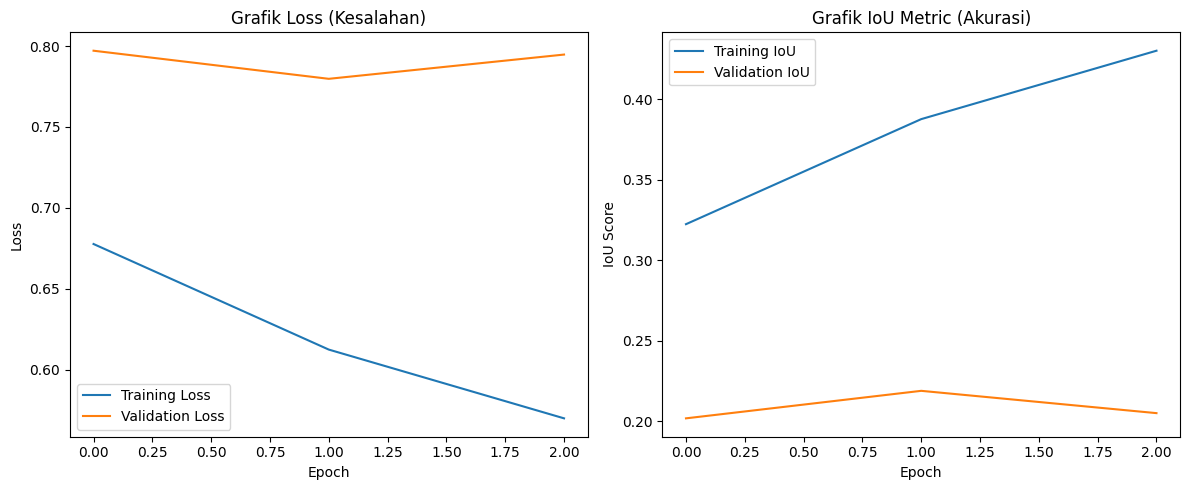

In [61]:
# %% [markdown]
# # SEL 8: Visualisasi Hasil Training (Learning Curve)
# Setelah selesai, kita bisa melihat grafik performa (grafik nilai loss/error dan nilai akurasi IoU)
# dari model kita pada setiap epoch-nya.

# %%
# Plot Nilai Loss (Kesalahan) -> Semakin turun semakin bagus
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss (Kesalahan)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Nilai IoU (Akurasi Segmentasi) -> Semakin naik semakin bagus
plt.subplot(1, 2, 2)
plt.plot(history.history['iou_metric'], label='Training IoU')
plt.plot(history.history['val_iou_metric'], label='Validation IoU')
plt.title('Grafik IoU Metric (Akurasi)')
plt.xlabel('Epoch')
plt.ylabel('IoU Score')
plt.legend()

plt.tight_layout()
plt.show()